# Imports

In [1]:
from nb_utils import set_root
PROJECT_DIR = set_root(1)

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from scipy.signal import convolve2d
from scipy.fft import ifft2
from scipy.fftpack import fft2, fftshift

# Methods

In [3]:
def load_image(image_path):
    image = Image.open(image_path).convert('L')
    return np.array(image)

def apply_fourier_transform(image):
    f_transform = np.fft.fft2(image)
    f_shift = np.fft.fftshift(f_transform)
    magnitude = np.log(np.abs(f_shift) + 1)
    fase = np.angle(f_transform)
    return magnitude, fase

def plot_images(dict_content: dict[str], figsize: tuple[int, int] = (12, 6), with_ax: bool=False, with_phase: bool=False) -> tuple[plt.Figure, np.ndarray]:
    if with_phase:
        fig, ax = plt.subplots(len(dict_content), 3, figsize=figsize)
    else:
        fig, ax = plt.subplots(len(dict_content), 2, figsize=figsize)

    if len(dict_content) == 1:
        ax = np.expand_dims(ax, axis=0)

    for idx, (key, value) in enumerate(dict_content.items()):
        ax[idx, 0].set_title("Imagem")
        ax[idx, 0].imshow(value["original"]["img"], **value["original"]["args"])
        ax[idx, 0].axis('off')

        ax[idx, 1].set_title("Transformada")
        ax[idx, 1].imshow(value["transformada"]["img"], **value["transformada"]["args"])

        if with_phase:
            ax[idx, 2].set_title("Fase")
            ax[idx, 2].imshow(value["fase"]["img"], **value["fase"]["args"])

        if not with_ax:
            ax[idx, 1].axis('off')

    fig.tight_layout()
    plt.show()
    return fig, ax

In [4]:
def apply_convolution(matrix, kernel):
    """
    Aplica a convolução entre uma matriz e um kernel.
    
    Args:
        matrix (np.ndarray): Matriz original.
        kernel (np.ndarray): Kernel para convolução.
    
    Returns:
        np.ndarray: Resultado da convolução.
    """
    result = convolve2d(matrix, kernel, mode='same', boundary='fill', fillvalue=0)
    return result

def plot_matrices(original, convolved, figsize=(10, 5)):
    """
    Plota a matriz original e a matriz convoluída lado a lado.
    
    Args:
        original (np.ndarray): Matriz original.
        convolved (np.ndarray): Matriz convoluída.
    """
    fig, axes = plt.subplots(1, len(convolved) + 1, figsize=figsize)

    axes[0].imshow(original, cmap='gray')
    axes[0].set_title("Matriz Original")
    axes[0].axis('off')

    for idx, (key, content) in enumerate(convolved.items()):

        axes[idx + 1].imshow(content, cmap='gray')
        axes[idx + 1].set_title(key)
        axes[idx + 1].axis('off')

    fig.tight_layout()
    
    return fig, axes

In [5]:
def compute_stft_magnitude(img: np.ndarray, window_size:int=64, step_size:int=32):
    """
    Calcula a magnitude local usando STFT.

    Args:
        img (np.ndarray): Imagem de entrada em escala de cinza.
        window_size (int): Tamanho da janela para a STFT.
        step_size (int): Passo entre as janelas.

    Returns:
        np.ndarray: magnitude local normalizado para visualização.
    """
    height, width = img.shape

    # Inicializa o mapa de magnitude local
    stft_magnitude = np.zeros((height, width))

    # Aplica a STFT (FFT local por janelas)
    for y in range(0, height - window_size, step_size):
        for x in range(0, width - window_size, step_size):
            window = img[y:y+window_size, x:x+window_size]
            fft_local = fftshift(fft2(window))  # transformada de fourier local e depois centraliza
            magnitude = np.log(1 + np.abs(fft_local))  # gera a manitude
            mean_magnitude = np.mean(magnitude)
            stft_magnitude[y:y+window_size, x:x+window_size] = mean_magnitude

    stft_magnitude = cv2.normalize(stft_magnitude, None, 0, 255, cv2.NORM_MINMAX) # normalizando para 0-255
    return stft_magnitude.astype(np.uint8)

In [6]:
def find_closest_palette_color(value):
    """
    Finds the closest palette color for a given pixel value.
    For 1-bit black-and-white, it rounds to 0 or 255.
    """
    return 0 if value < 127 else 255

def floyd_steinberg_dithering(image):
    """
    Applies the Floyd-Steinberg dithering algorithm to a grayscale image.

    :param image: A numpy array representing the grayscale image.
    :return: A numpy array representing the binarized image.
    """
    # Convert the image to float to avoid overflow during error propagation
    pixels = image.astype(float)
    height, width = pixels.shape

    for y in range(height):
        for x in range(width):
            oldpixel = pixels[y, x]
            newpixel = find_closest_palette_color(oldpixel)
            pixels[y, x] = newpixel
            print(f"old_pixel: {oldpixel}")
            quant_error = oldpixel - newpixel
            print(f"-- P({y}, {x})")
            # Propagate the quantization error to neighboring pixels
            if x + 1 < width:
                txt = f"------------- P({y}, {x + 1}) = {pixels[y, x + 1]}+ {quant_error} * 7/16 = "
                pixels[y, x + 1] += quant_error * 7 / 16
                txt += str(pixels[y, x + 1])
                print(f"------------- {txt}")
            if x - 1 >= 0 and y + 1 < height:
                txt = f"------------- P({y + 1}, {x - 1}) = {pixels[y + 1, x - 1]} + {quant_error} * 3/16 = "
                pixels[y + 1, x - 1] += quant_error * 3 / 16
                txt += str(pixels[y + 1, x - 1])
                print(f"------------- {txt}")
            if y + 1 < height:
                txt = f"------------- P({y + 1}, {x}) = {pixels[y + 1, x]} + {quant_error} * 5/16 = "
                pixels[y + 1, x] += quant_error * 5 / 16
                txt += str(pixels[y + 1, x])
                print(f"------------- {txt}")
            if x + 1 < width and y + 1 < height:
                txt = f"------------- P({y + 1}, {x + 1}) = {pixels[y + 1, x + 1]} + {quant_error} * 1/16 = "
                pixels[y + 1, x + 1] += quant_error * 1 / 16
                txt += str(pixels[y + 1, x + 1])
                print(f"------------- {txt}")
            print(f"-- result: \n {pixels}")
            print()
        print()
        print()
    # Clip the values to ensure they remain within the valid range [0, 255]
    return np.clip(pixels, 0, 255).astype(np.uint8)

# Questão 01

In [11]:
from PIL import Image
import cv2
from scipy.signal import convolve2d
from scipy.fftpack import fft2, fftshift

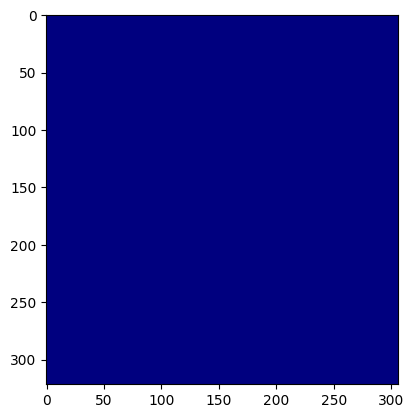

In [33]:
img = load_image(PROJECT_DIR / "assets" / "99_test_i03.png")
transform = apply_fourier_transform(img)
plt.imshow(transform[0], cmap="jet")

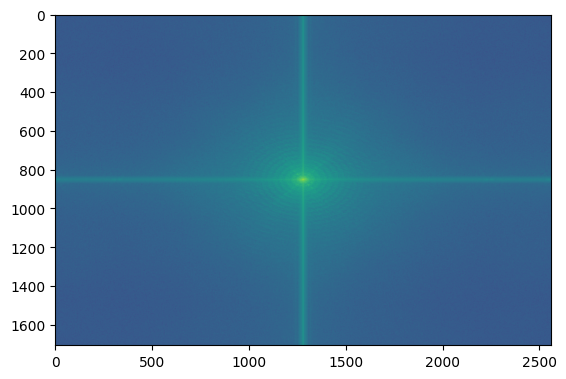

In [ ]:
h = [
[0, 1,  0] ,
[1, -4, 1],
[0, 1 , 0]
]


f = [
[1, 3, 0],
[2, 2, 3],
[1, 3, 1]
]

In [35]:
convolve2d(
        f,
        h,
        mode='same',
        boundary='fill',
        fillvalue=0
    )

array([[ 1, -9,  6],
       [-4,  3, -9],
       [ 1, -8,  2]])